# Gaussian-Mixture MIP Rendering

This notebook loads a trained 3D Gaussian mixture, reconstructs the dense volume, and renders a mathematically consistent Z-axis maximum-intensity projection.

The correct rendering equation is

\[
M(x,y)=\max_z\sum_i I_i
\exp\left[
-\frac{1}{2}
(\mathbf p-\boldsymbol\mu_i)^T
\boldsymbol\Sigma_i^{-1}
(\mathbf p-\boldsymbol\mu_i)
\right].
\]

This differs from taking a maximum over independently projected splats:

\[
\max_i I_iG_i(x,y).
\]

The renderer below sums all Gaussian contributions at each depth sample, then takes the maximum across depth.

## 1. Imports and configuration

In [2]:
%matplotlib inline

from __future__ import annotations

import argparse
import sys
import time
from dataclasses import dataclass
from pathlib import Path

import h5py
import matplotlib.pyplot as plt
import numpy as np
import torch
import torch.nn.functional as F

torch.set_grad_enabled(False)

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

DATA_PATH = Path("../data/smoke_data/blocks/block_z0_y1_x6.h5")
CHECKPOINT_PATH = Path("../models_smoke/block_z000_y001_x006/best.pth")
SCRIPTS_PATH = Path("../scripts")

MAHALANOBIS_CUTOFF = 20.0
PIXEL_CHUNK_SIZE = 256
GAUSSIAN_CHUNK_SIZE = 1024

# FPS-benchmark parameters (see "FPS benchmark" section below)
FPS_WARMUP_ITERS = 3
FPS_BENCHMARK_ITERS = 10

print("Device:", DEVICE)
print("Data:", DATA_PATH)
print("Checkpoint:", CHECKPOINT_PATH)

Device: cuda
Data: ../data/smoke_data/blocks/block_z0_y1_x6.h5
Checkpoint: ../models_smoke/block_z000_y001_x006/best.pth


## 2. Load and inspect the ground-truth volume

Volume shape: (50, 50, 50)
Volume range: 0.0 1.0
GT MIP range: 0.7445255517959595 1.0


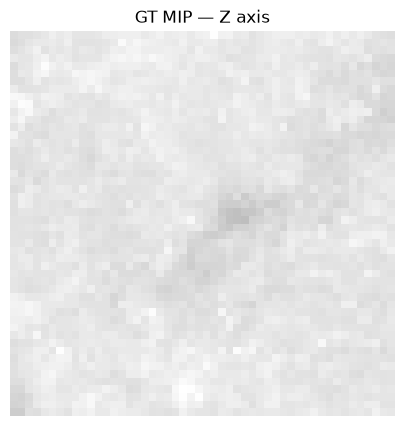

In [3]:
def load_normalized_volume(path: Path) -> np.ndarray:
    with h5py.File(path, "r") as file:
        volume = np.asarray(file["raw"], dtype=np.float32)

    value_min = float(volume.min())
    value_max = float(volume.max())

    if value_max <= value_min:
        raise ValueError("The input volume has no dynamic range.")

    return (volume - value_min) / (value_max - value_min)


volume_gt = load_normalized_volume(DATA_PATH)
D, H, W = volume_gt.shape
gt_mip = volume_gt.max(axis=0)

print("Volume shape:", volume_gt.shape)
print("Volume range:", float(volume_gt.min()), float(volume_gt.max()))
print("GT MIP range:", float(gt_mip.min()), float(gt_mip.max()))

plt.figure(figsize=(5, 5))
plt.imshow(gt_mip, cmap="gray", vmin=0.0, vmax=1.0)
plt.title("GT MIP — Z axis")
plt.axis("off")
plt.show()

## 3. Gaussian representation and covariance construction

In [4]:
@dataclass
class Gaussian3D:
    means: torch.Tensor          # [P, 3]
    scales: torch.Tensor         # [P, 3]
    rotations: torch.Tensor      # [P, 3, 3]
    intensities: torch.Tensor    # [P]


def quaternion_to_rotation_matrix(
    quaternions: torch.Tensor,
    scalar_first: bool = True,
) -> torch.Tensor:
    """
    Convert normalized quaternions to rotation matrices.

    scalar_first=True expects [w, x, y, z].
    scalar_first=False expects [x, y, z, w].
    """
    if quaternions.ndim != 2 or quaternions.shape[-1] != 4:
        raise ValueError(
            f"Expected [P, 4] quaternions, received {tuple(quaternions.shape)}"
        )

    q = F.normalize(quaternions, dim=-1, eps=1e-8)

    if scalar_first:
        w, x, y, z = q.unbind(dim=-1)
    else:
        x, y, z, w = q.unbind(dim=-1)

    entries = torch.stack(
        (
            1.0 - 2.0 * (y.square() + z.square()),
            2.0 * (x * y - z * w),
            2.0 * (x * z + y * w),

            2.0 * (x * y + z * w),
            1.0 - 2.0 * (x.square() + z.square()),
            2.0 * (y * z - x * w),

            2.0 * (x * z - y * w),
            2.0 * (y * z + x * w),
            1.0 - 2.0 * (x.square() + y.square()),
        ),
        dim=-1,
    )

    return entries.reshape(-1, 3, 3)


def covariance_from_scale_rotation(
    scales: torch.Tensor,
    rotations: torch.Tensor,
) -> torch.Tensor:
    """
    Sigma = R diag(s_x^2, s_y^2, s_z^2) R^T.
    """
    if scales.ndim != 2 or scales.shape[-1] != 3:
        raise ValueError(f"Expected scales [P, 3], received {tuple(scales.shape)}")

    if rotations.shape != (scales.shape[0], 3, 3):
        raise ValueError(
            f"Expected rotations [{scales.shape[0]}, 3, 3], "
            f"received {tuple(rotations.shape)}"
        )

    return (
        rotations
        @ torch.diag_embed(scales.square())
        @ rotations.transpose(-1, -2)
    )

## 4. Load the trained Gaussian cloud

In [5]:
if str(SCRIPTS_PATH) not in sys.path:
    sys.path.insert(0, str(SCRIPTS_PATH))

import _3dgs._3dgs as _mod
from _3dgs._3dgs import AABB, GaussianCloud, VolumeDataset

_mod.USE_CUDA_KERNEL = True
_mod._load_3dgs_kernel()

# The training module may select a headless Matplotlib backend.
%matplotlib inline

cfg_rec = argparse.Namespace(
    scale_min_clamp=1e-5,
    mahal_max_clamp=MAHALANOBIS_CUTOFF,
    init_scale=0.05,
    init_inten=0.1,
    init_scale_z_factor=1.0,
    n_init=5000,
    swc_path=None,
    chunk_n=1000,
    eval_samples=200_000,
    ssim_crop=50,
    batch=2048,
    grad_sample_weight=0.0,
    lambda_ssim=0.2,
)

aabb = AABB.unit()

gaussian_cloud = GaussianCloud.load(
    str(CHECKPOINT_PATH),
    aabb,
    DEVICE,
    cfg_rec,
)

gaussians = Gaussian3D(
    means=gaussian_cloud.means.detach(),
    scales=torch.exp(gaussian_cloud.log_s.detach()),
    rotations=quaternion_to_rotation_matrix(
        gaussian_cloud.quats.detach(),
        scalar_first=True,
    ),
    intensities=gaussian_cloud.intensity().detach().reshape(-1),
)

print("Number of Gaussians:", gaussians.means.shape[0])
print("Means min:", gaussians.means.amin(dim=0).cpu().tolist())
print("Means max:", gaussians.means.amax(dim=0).cpu().tolist())
print("Scale range:", float(gaussians.scales.min()), float(gaussians.scales.max()))
print(
    "Intensity range:",
    float(gaussians.intensities.min()),
    float(gaussians.intensities.max()),
)

/venv/r3-ml/lib/python3.11/site-packages/torch/utils/cpp_extension.py:1964: UserWarning: TORCH_CUDA_ARCH_LIST is not set, all archs for visible cards are included for compilation. 
If this is not desired, please set os.environ['TORCH_CUDA_ARCH_LIST'].
  warnings.warn(
/root/project/notebooks/../scripts/_3dgs/_3dgs.py:1008: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recomme

Number of Gaussians: 50000
Means min: [-1.0, -0.9999995231628418, -0.9999990463256836]
Means max: [0.9999996423721313, 1.0, 1.0]
Scale range: 0.0005783138913102448 0.18765947222709656
Intensity range: 0.005004881881177425 0.7605141401290894


## 5. Dense reconstruction using the original GaussianCloud model

Dense reconstruction range: 0.04576926305890083 1.0
Dense reconstruction PSNR: 47.649 dB


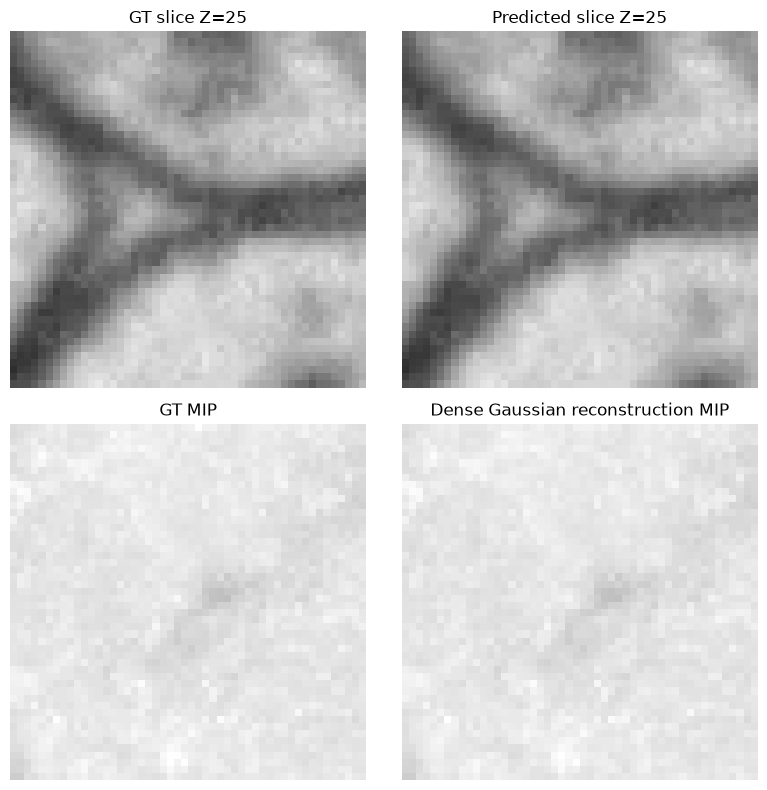

In [6]:
def reconstruct_dense_volume(
    model: GaussianCloud,
    volume: np.ndarray,
    bounding_box: AABB,
    config: argparse.Namespace,
    device: torch.device,
) -> np.ndarray:
    volume_tensor = torch.from_numpy(volume).float()
    dataset = VolumeDataset(volume_tensor, bounding_box, config)

    depth, height, width = dataset.D, dataset.H, dataset.W
    reconstruction = np.empty((depth, height, width), dtype=np.float32)

    with torch.no_grad():
        for z_index in range(depth):
            points = dataset._indices_to_pts(
                torch.full((height * width,), z_index, dtype=torch.long),
                torch.arange(height, dtype=torch.long).repeat_interleave(width),
                torch.arange(width, dtype=torch.long).tile(height),
                device,
            )

            values = model.forward(
                points,
                chunk_n=config.chunk_n,
            ).clamp(0.0, 1.0)

            reconstruction[z_index] = (
                values.cpu().numpy().reshape(height, width)
            )

    return reconstruction


volume_pred = reconstruct_dense_volume(
    model=gaussian_cloud,
    volume=volume_gt,
    bounding_box=aabb,
    config=cfg_rec,
    device=DEVICE,
)

dense_mip = volume_pred.max(axis=0)

mse = float(np.mean((volume_pred - volume_gt) ** 2))
psnr = -10.0 * np.log10(max(mse, 1e-12))

print("Dense reconstruction range:", float(volume_pred.min()), float(volume_pred.max()))
print(f"Dense reconstruction PSNR: {psnr:.3f} dB")

middle_z = D // 2

fig, axes = plt.subplots(2, 2, figsize=(8, 8))
axes[0, 0].imshow(volume_gt[middle_z], cmap="gray", vmin=0, vmax=1)
axes[0, 0].set_title(f"GT slice Z={middle_z}")
axes[0, 1].imshow(volume_pred[middle_z], cmap="gray", vmin=0, vmax=1)
axes[0, 1].set_title(f"Predicted slice Z={middle_z}")
axes[1, 0].imshow(gt_mip, cmap="gray", vmin=0, vmax=1)
axes[1, 0].set_title("GT MIP")
axes[1, 1].imshow(dense_mip, cmap="gray", vmin=0, vmax=1)
axes[1, 1].set_title("Dense Gaussian reconstruction MIP")

for axis in axes.ravel():
    axis.axis("off")

plt.tight_layout()
plt.show()

## 6. Correct direct Gaussian-mixture MIP renderer

For each pixel and each sampled depth:

1. create the 3D query point;
2. evaluate all 3D Gaussians;
3. sum all valid contributions;
4. take the maximum summed density over depth.

This operation matches the field represented by `GaussianCloud.forward`.

In [7]:
def make_volume_coordinates(
    aabb: AABB,
    depth: int,
    height: int,
    width: int,
    device: torch.device,
    dtype: torch.dtype,
) -> tuple[torch.Tensor, torch.Tensor, torch.Tensor]:
    """
    Create the same align_corners=True coordinate grid used by
    VolumeDataset._indices_to_pts.
    """
    lower = aabb.lo.to(device=device, dtype=dtype)
    upper = aabb.hi.to(device=device, dtype=dtype)

    x_coordinates = torch.linspace(
        lower[0], upper[0], width, device=device, dtype=dtype
    )
    y_coordinates = torch.linspace(
        lower[1], upper[1], height, device=device, dtype=dtype
    )
    z_coordinates = torch.linspace(
        lower[2], upper[2], depth, device=device, dtype=dtype
    )

    return x_coordinates, y_coordinates, z_coordinates


def evaluate_gaussian_mixture_at_points(
    points: torch.Tensor,
    means: torch.Tensor,
    precisions: torch.Tensor,
    intensities: torch.Tensor,
    mahalanobis_cutoff: float,
    gaussian_chunk_size: int,
) -> torch.Tensor:
    """
    Evaluate sum_i I_i exp(-0.5 d_i^2) at N three-dimensional points.
    """
    density = torch.zeros(
        points.shape[0],
        device=points.device,
        dtype=points.dtype,
    )

    for start in range(0, means.shape[0], gaussian_chunk_size):
        end = min(start + gaussian_chunk_size, means.shape[0])

        means_chunk = means[start:end]
        precision_chunk = precisions[start:end]
        intensity_chunk = intensities[start:end]

        delta = points[:, None, :] - means_chunk[None, :, :]

        mahalanobis_squared = torch.einsum(
            "ngi,gij,ngj->ng",
            delta,
            precision_chunk,
            delta,
        )

        valid = (
            torch.isfinite(mahalanobis_squared)
            & (mahalanobis_squared >= 0.0)
            & (mahalanobis_squared <= mahalanobis_cutoff)
        )

        contributions = (
            torch.exp(-0.5 * mahalanobis_squared)
            * intensity_chunk[None, :]
        )

        density += torch.where(
            valid,
            contributions,
            torch.zeros_like(contributions),
        ).sum(dim=1)

    return density


@torch.no_grad()
def render_gaussian_mixture_mip(
    gaussians: Gaussian3D,
    aabb: AABB,
    depth: int,
    height: int,
    width: int,
    mahalanobis_cutoff: float = 20.0,
    pixel_chunk_size: int = 256,
    gaussian_chunk_size: int = 1024,
) -> tuple[torch.Tensor, torch.Tensor]:
    """
    Render M(x,y) = max_z sum_i I_i G_i(x,y,z).

    Returns:
        mip_image: [H, W]
        winner_z:  [H, W] discrete winning Z index
    """
    device = gaussians.means.device
    dtype = gaussians.means.dtype

    covariance = covariance_from_scale_rotation(
        gaussians.scales,
        gaussians.rotations,
    )
    precision = torch.linalg.inv(covariance)

    x_coordinates, y_coordinates, z_coordinates = make_volume_coordinates(
        aabb=aabb,
        depth=depth,
        height=height,
        width=width,
        device=device,
        dtype=dtype,
    )

    y_grid, x_grid = torch.meshgrid(
        y_coordinates,
        x_coordinates,
        indexing="ij",
    )
    xy = torch.stack((x_grid, y_grid), dim=-1).reshape(-1, 2)

    number_of_pixels = xy.shape[0]

    mip_flat = torch.full(
        (number_of_pixels,),
        -torch.inf,
        device=device,
        dtype=dtype,
    )
    winner_z_flat = torch.full(
        (number_of_pixels,),
        -1,
        device=device,
        dtype=torch.long,
    )

    for pixel_start in range(0, number_of_pixels, pixel_chunk_size):
        pixel_end = min(pixel_start + pixel_chunk_size, number_of_pixels)
        xy_chunk = xy[pixel_start:pixel_end]

        best_density = torch.full(
            (xy_chunk.shape[0],),
            -torch.inf,
            device=device,
            dtype=dtype,
        )
        best_z_index = torch.full(
            (xy_chunk.shape[0],),
            -1,
            device=device,
            dtype=torch.long,
        )

        for z_index, z_value in enumerate(z_coordinates):
            points = torch.cat(
                (
                    xy_chunk,
                    torch.full(
                        (xy_chunk.shape[0], 1),
                        z_value,
                        device=device,
                        dtype=dtype,
                    ),
                ),
                dim=-1,
            )

            density = evaluate_gaussian_mixture_at_points(
                points=points,
                means=gaussians.means,
                precisions=precision,
                intensities=gaussians.intensities,
                mahalanobis_cutoff=mahalanobis_cutoff,
                gaussian_chunk_size=gaussian_chunk_size,
            )

            improved = density > best_density
            best_density = torch.where(improved, density, best_density)
            best_z_index = torch.where(
                improved,
                torch.full_like(best_z_index, z_index),
                best_z_index,
            )

        mip_flat[pixel_start:pixel_end] = best_density
        winner_z_flat[pixel_start:pixel_end] = best_z_index

    mip_flat[~torch.isfinite(mip_flat)] = 0.0

    return (
        mip_flat.reshape(height, width),
        winner_z_flat.reshape(height, width),
    )

## 7. Render the corrected MIP

In [8]:
mixture_mip, winner_z = render_gaussian_mixture_mip(
    gaussians=gaussians,
    aabb=aabb,
    depth=D,
    height=H,
    width=W,
    mahalanobis_cutoff=cfg_rec.mahal_max_clamp,
    pixel_chunk_size=PIXEL_CHUNK_SIZE,
    gaussian_chunk_size=GAUSSIAN_CHUNK_SIZE,
)

mixture_mip_np = mixture_mip.cpu().numpy()

print(
    "Direct Gaussian-mixture MIP range:",
    float(mixture_mip.min()),
    float(mixture_mip.max()),
)
print(
    "Winning Z-index range:",
    int(winner_z.min()),
    int(winner_z.max()),
)

Direct Gaussian-mixture MIP range: 0.7483989596366882 1.0024183988571167
Winning Z-index range: 0 49


## 8. Compare all MIP results

Dense MIP vs GT:  MSE=0.00000945, PSNR=50.246 dB
Direct MIP vs GT: MSE=0.00000945, PSNR=50.245 dB
Direct vs dense:  MSE=0.00000000, PSNR=86.309 dB


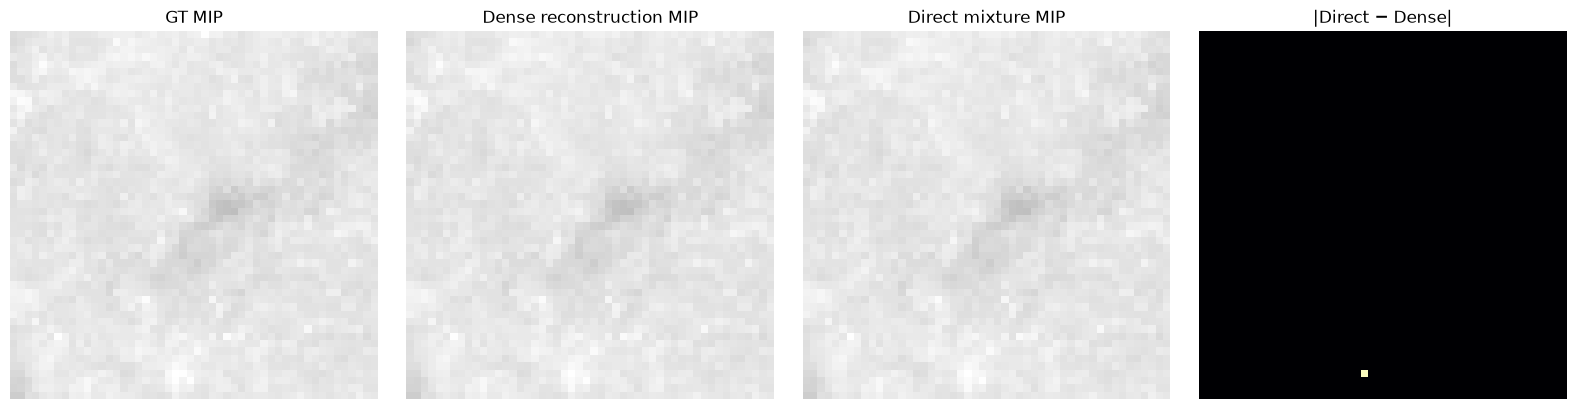

In [9]:
def compute_image_metrics(
    prediction: np.ndarray,
    target: np.ndarray,
) -> tuple[float, float]:
    error = prediction.astype(np.float64) - target.astype(np.float64)
    mse = float(np.mean(error ** 2))
    psnr = -10.0 * np.log10(max(mse, 1e-12))
    return mse, psnr


dense_mip_mse, dense_mip_psnr = compute_image_metrics(dense_mip, gt_mip)
direct_mip_mse, direct_mip_psnr = compute_image_metrics(mixture_mip_np, gt_mip)
direct_vs_dense_mse, direct_vs_dense_psnr = compute_image_metrics(
    mixture_mip_np,
    dense_mip,
)

print(
    f"Dense MIP vs GT:  MSE={dense_mip_mse:.8f}, "
    f"PSNR={dense_mip_psnr:.3f} dB"
)
print(
    f"Direct MIP vs GT: MSE={direct_mip_mse:.8f}, "
    f"PSNR={direct_mip_psnr:.3f} dB"
)
print(
    f"Direct vs dense:  MSE={direct_vs_dense_mse:.8f}, "
    f"PSNR={direct_vs_dense_psnr:.3f} dB"
)

fig, axes = plt.subplots(1, 4, figsize=(16, 4))

axes[0].imshow(gt_mip, cmap="gray", vmin=0.0, vmax=1.0)
axes[0].set_title("GT MIP")

axes[1].imshow(dense_mip, cmap="gray", vmin=0.0, vmax=1.0)
axes[1].set_title("Dense reconstruction MIP")

axes[2].imshow(mixture_mip_np, cmap="gray", vmin=0.0, vmax=1.0)
axes[2].set_title("Direct mixture MIP")

difference = np.abs(mixture_mip_np - dense_mip)
axes[3].imshow(difference, cmap="magma")
axes[3].set_title("|Direct − Dense|")

for axis in axes:
    axis.axis("off")

plt.tight_layout()
plt.show()

## 9. Validate selected pixels

In [10]:
test_pixels = [
    (0, 0),
    (H // 4, W // 4),
    (H // 2, W // 2),
    (3 * H // 4, 3 * W // 4),
    (H - 1, W - 1),
]

for y, x in test_pixels:
    dense_value = float(dense_mip[y, x])
    direct_value = float(mixture_mip_np[y, x])
    z_index = int(winner_z[y, x])

    print(
        f"(y={y:02d}, x={x:02d}) "
        f"dense={dense_value:.6f}, "
        f"direct={direct_value:.6f}, "
        f"winning_z={z_index}"
    )

(y=00, x=00) dense=0.861536, direct=0.861536, winning_z=11
(y=12, x=12) dense=0.918405, direct=0.918405, winning_z=46
(y=25, x=25) dense=0.861229, direct=0.861229, winning_z=46
(y=37, x=37) dense=0.919941, direct=0.919941, winning_z=23
(y=49, x=49) dense=0.904913, direct=0.904914, winning_z=17


## 10. Optional continuous-depth approximation

The default renderer samples exactly \(D\) depth positions, matching the voxel grid.  
Using more depth samples estimates the continuous MIP more closely, although it will no longer be identical to the discrete voxel MIP.

In [11]:
# Example:
#
# continuous_mip, continuous_winner_z = render_gaussian_mixture_mip(
#     gaussians=gaussians,
#     aabb=aabb,
#     depth=4 * D,
#     height=H,
#     width=W,
#     mahalanobis_cutoff=cfg_rec.mahal_max_clamp,
#     pixel_chunk_size=PIXEL_CHUNK_SIZE,
#     gaussian_chunk_size=GAUSSIAN_CHUNK_SIZE,
# )
#
# plt.figure(figsize=(5, 5))
# plt.imshow(continuous_mip.cpu(), cmap="gray")
# plt.title("Continuous-depth approximation")
# plt.axis("off")
# plt.show()

## 11. CUDA kernel target

The CUDA implementation should preserve this operation order:

```text
for each image tile
    select Gaussians whose 3D support may affect the tile

    for each pixel
        best_density = 0

        for each depth slab
            density_at_depth = 0

            for each candidate Gaussian
                density_at_depth += intensity * exp(-0.5 * mahalanobis_3d)

            best_density = max(best_density, density_at_depth)
```

For this trained representation, replacing the inner sum with a maximum over independent 2D splats changes the represented field and produces an incorrect MIP.

## 12. FPS benchmark

Baseline throughput for the reference PyTorch mixture-MIP renderer
(section 6) — the number the future CUDA kernel (section 11) should be
compared against. Timed with warmup iterations and `torch.cuda.synchronize()`
around the timed loop so async kernel launches don't skew the measurement.

In [12]:
def benchmark_render_fps(
    render_fn,
    warmup_iters: int = FPS_WARMUP_ITERS,
    benchmark_iters: int = FPS_BENCHMARK_ITERS,
) -> tuple[float, float]:
    """Time a zero-arg render callable. Returns (ms_per_frame, fps)."""
    for _ in range(warmup_iters):
        render_fn()
    if DEVICE.type == "cuda":
        torch.cuda.synchronize()

    start = time.perf_counter()
    for _ in range(benchmark_iters):
        render_fn()
    if DEVICE.type == "cuda":
        torch.cuda.synchronize()
    elapsed = time.perf_counter() - start

    ms_per_frame = elapsed / benchmark_iters * 1000.0
    fps = 1000.0 / ms_per_frame
    return ms_per_frame, fps


mixture_ms_per_frame, mixture_fps = benchmark_render_fps(
    lambda: render_gaussian_mixture_mip(
        gaussians=gaussians,
        aabb=aabb,
        depth=D,
        height=H,
        width=W,
        mahalanobis_cutoff=cfg_rec.mahal_max_clamp,
        pixel_chunk_size=PIXEL_CHUNK_SIZE,
        gaussian_chunk_size=GAUSSIAN_CHUNK_SIZE,
    )
)

print(f"Direct Gaussian-mixture MIP: {mixture_ms_per_frame:.2f} ms/frame  ->  {mixture_fps:.2f} FPS")
print(
    f"({gaussians.means.shape[0]:,} Gaussians, {D}x{H}x{W} volume, "
    f"pixel_chunk_size={PIXEL_CHUNK_SIZE}, gaussian_chunk_size={GAUSSIAN_CHUNK_SIZE}, "
    f"warmup={FPS_WARMUP_ITERS}, reps={FPS_BENCHMARK_ITERS})"
)

Direct Gaussian-mixture MIP: 5662.16 ms/frame  ->  0.18 FPS
(50,000 Gaussians, 50x50x50 volume, pixel_chunk_size=256, gaussian_chunk_size=1024, warmup=3, reps=10)


## 13. Camera position at the block centre

Places a viewpoint at the geometric centre of the block — voxel index
`(D/2, H/2, W/2)`, converted to AABB world coordinates with the same
linspace convention `make_volume_coordinates` uses elsewhere in this
notebook — and visualises it against the Gaussian point cloud and the
AABB with Open3D.

Block centre (voxel index (25.0, 25.0, 25.0)) -> world [0.020408153533935547, 0.020408153533935547, 0.020408153533935547]
Jupyter environment detected. Enabling Open3D WebVisualizer.
[Open3D INFO] WebRTC GUI backend enabled.
[Open3D INFO] WebRTCWindowSystem: HTTP handshake server disabled.
[Open3D INFO] EGL headless mode enabled.
FEngine (64 bits) created at 0x7f2fe8066010 (threading is enabled)
EGL(1.5)
OpenGL(4.5)


libEGL warning: DRI3 error: Could not get DRI3 device
libEGL warning: Ensure your X server supports DRI3 to get accelerated rendering


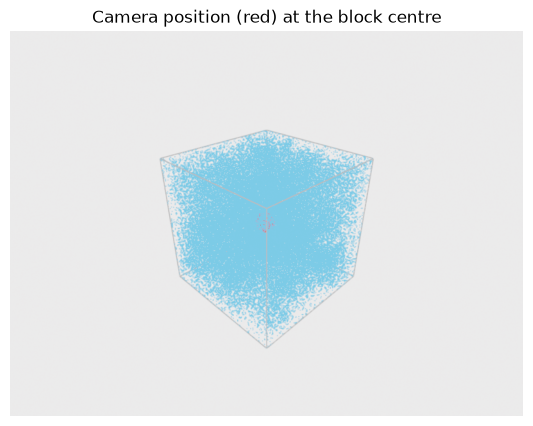

In [13]:
def voxel_index_to_world(
    index_xyz: tuple[float, float, float],
    aabb: AABB,
    size_xyz: tuple[float, float, float],
    device: torch.device,
    dtype: torch.dtype = torch.float32,
) -> torch.Tensor:
    """
    Convert a (possibly fractional) voxel index to AABB world coordinates,
    using the same linspace convention as make_volume_coordinates /
    VolumeDataset._indices_to_pts.
    """
    lower = aabb.lo.to(device=device, dtype=dtype)
    upper = aabb.hi.to(device=device, dtype=dtype)
    index = torch.tensor(index_xyz, device=device, dtype=dtype)
    size = torch.tensor(size_xyz, device=device, dtype=dtype)
    return lower + (index / (size - 1.0)) * (upper - lower)


CAMERA_POSITION = voxel_index_to_world(
    index_xyz=(W / 2.0, H / 2.0, D / 2.0),
    aabb=aabb,
    size_xyz=(W, H, D),
    device=DEVICE,
)
print(
    f"Block centre (voxel index {(W / 2.0, H / 2.0, D / 2.0)}) "
    f"-> world {CAMERA_POSITION.tolist()}"
)

# importing open3d resets matplotlib's backend away from the Jupyter
# inline backend; restore it so plt.show() below still renders.
import open3d as o3d
%matplotlib inline

means_np = gaussians.means.detach().cpu().numpy().astype(np.float64)
colors = np.tile(np.array([[0.2, 0.6, 0.9]]), (means_np.shape[0], 1))

pcd = o3d.geometry.PointCloud()
pcd.points = o3d.utility.Vector3dVector(means_np)
pcd.colors = o3d.utility.Vector3dVector(colors)

lo_np = aabb.lo.cpu().numpy().astype(np.float64)
hi_np = aabb.hi.cpu().numpy().astype(np.float64)
corners = np.array([[x, y, z] for x in (lo_np[0], hi_np[0])
                               for y in (lo_np[1], hi_np[1])
                               for z in (lo_np[2], hi_np[2])])
edges = [(0,1),(0,2),(0,4),(1,3),(1,5),(2,3),(2,6),(3,7),(4,5),(4,6),(5,7),(6,7)]
box = o3d.geometry.LineSet(
    points=o3d.utility.Vector3dVector(corners),
    lines=o3d.utility.Vector2iVector(edges),
)
box.paint_uniform_color([0.5, 0.5, 0.5])

camera_marker = o3d.geometry.TriangleMesh.create_sphere(radius=0.15)
camera_marker.translate(CAMERA_POSITION.cpu().numpy().astype(np.float64))
camera_marker.paint_uniform_color([0.9, 0.1, 0.1])
camera_marker.compute_vertex_normals()

renderer = o3d.visualization.rendering.OffscreenRenderer(800, 600)
renderer.scene.set_background([1, 1, 1, 1])

mat_pts = o3d.visualization.rendering.MaterialRecord()
mat_pts.shader = "defaultUnlit"
mat_pts.point_size = 2.0

mat_lines = o3d.visualization.rendering.MaterialRecord()
mat_lines.shader = "unlitLine"
mat_lines.line_width = 2.0

mat_marker = o3d.visualization.rendering.MaterialRecord()
mat_marker.shader = "defaultUnlit"

renderer.scene.add_geometry("points", pcd, mat_pts)
renderer.scene.add_geometry("box", box, mat_lines)
renderer.scene.add_geometry("camera", camera_marker, mat_marker)

eye = np.array([3.0, 2.5, -3.0])
center = np.array([0.0, 0.0, 0.0])
up = np.array([0.0, 1.0, 0.0])
renderer.setup_camera(60.0, center, eye, up)

img = np.asarray(renderer.render_to_image())
plt.figure(figsize=(7, 5))
plt.imshow(img)
plt.title("Camera position (red) at the block centre")
plt.axis('off')
plt.show()